## Function Transformer

##### Feature Transformation : (Mathematical Transformation) : applying formula .

Function Transform
1.log transform
2.reciprocal 

power transform
4. box-cox transform
5. yeo-johnson

In [1]:
# It converts data/distribution into normal distribution.

<b> How to find if data is normal?</b>
--> sns.distplot()  (get to know about skewness)

--->pd.skew()

--> qq plot()

### Log Transform 

On Titanic Dataset , (AGE)

* Doesn't applied on -ve values.
* Applied on right skewed data
* Data get plotted on same scaled ( for linear regression ) ang values get linearly distributed.


#### Resiprocal Transforms (1/x)

Resiprocal of bigger values into smaller values and vice versa.



#### Square Transform (x^2)

Used for left skewwed data.


In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv("dataset/train.csv",usecols=["Age","Fare","Survived"])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [7]:
df.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

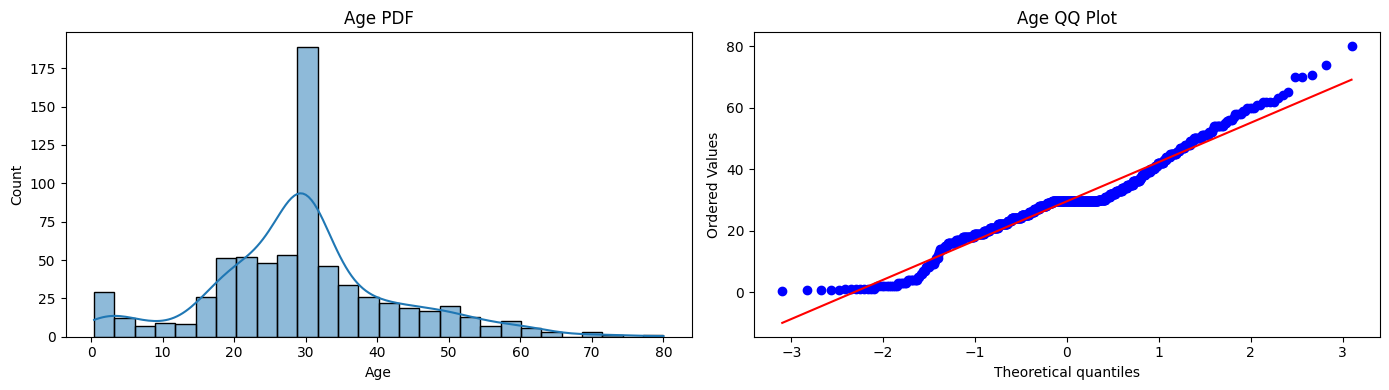

In [10]:
plt.figure(figsize=(14,4))

# PDF / Distribution Plot
plt.subplot(121)
sns.histplot(X_train["Age"], kde=True)
plt.title("Age PDF")

# QQ Plot
plt.subplot(122)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.tight_layout()
plt.show()

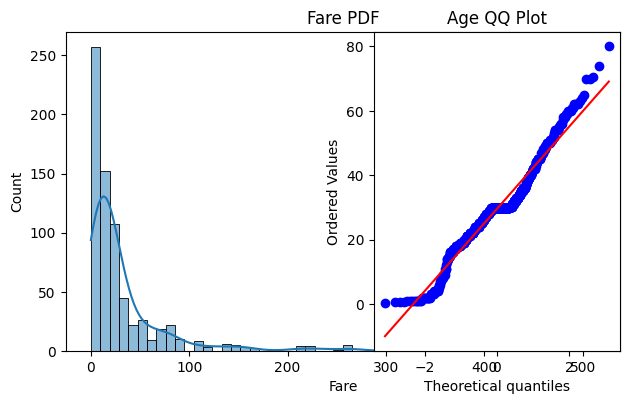

In [11]:
plt.Figure(figsize=(14,5))
plt.subplot(111)
sns.histplot(X_train["Fare"], kde=True)
plt.title("Fare PDF")

# QQ Plot
plt.subplot(122)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.tight_layout()
plt.show()

In [12]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139


In [14]:
trf=FunctionTransformer(func=np.log1p)  # add 1 to value incase log of value is zero/ value itself is zero.

In [15]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.fit_transform(X_test)

In [16]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()


clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred=clf.predict(X_test_transformed)
y_pred1=clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


In [17]:
## try again with cross validation

X_tranformed=trf.fit_transform(X)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_tranformed,y,scoring="accuracy",cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_tranformed,y,scoring="accuracy",cv=10)))

LR 0.678027465667915
DT 0.6599625468164794


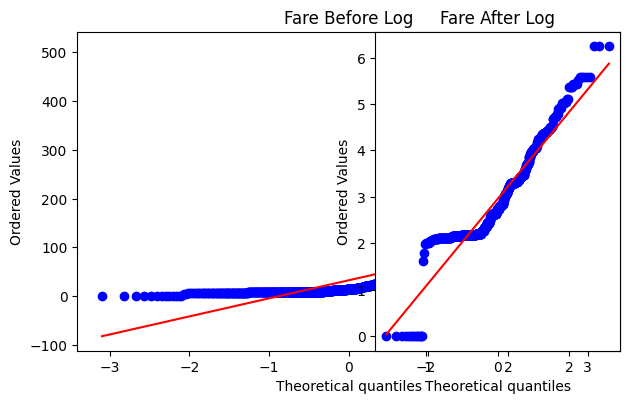

In [18]:
plt.Figure(figsize=(14,2))
plt.subplot(111)
stats.probplot(X_train["Fare"],dist="norm", plot=plt)
plt.title("Fare Before Log")

# QQ Plot
plt.subplot(122)
stats.probplot(X_train_transformed["Fare"], dist="norm", plot=plt)
plt.title("Fare After Log")

plt.tight_layout()
plt.show()

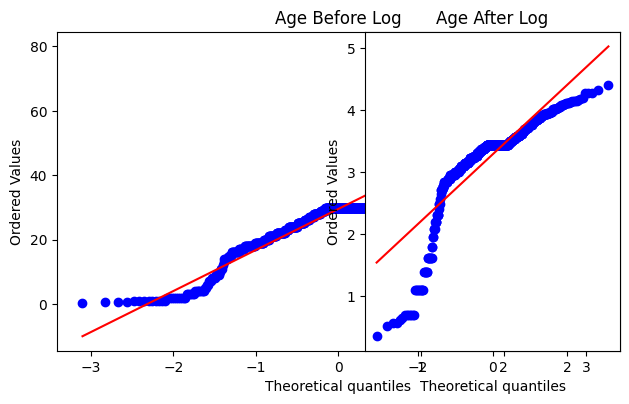

In [19]:
plt.Figure(figsize=(14,4))
plt.subplot(111)
stats.probplot(X_train["Age"],dist="norm", plot=plt)
plt.title("Age Before Log")

# QQ Plot
plt.subplot(122)
stats.probplot(X_train_transformed["Age"], dist="norm", plot=plt)
plt.title("Age After Log")

plt.tight_layout()
plt.show()

In [20]:
# age somehow got more worse at we tried it to assume it right skewed.

In [21]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),["Fare"])],remainder='passthrough')

X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)

In [22]:
# Rather than trying to applying log transformation on both of the age,fare . we apply function transformer on fare only.
# So we made column transformer


In [23]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()


clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred=clf.predict(X_test_transformed2)
y_pred1=clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6815642458100558


In [24]:
X_tranformed2=trf2.fit_transform(X)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_tranformed2,y,scoring="accuracy",cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_tranformed2,y,scoring="accuracy",cv=10)))

LR 0.6712609238451936
DT 0.6599500624219725


In [25]:
# age is normally distributed.
# fare is right skewed.

In [29]:
def apply_transform(transform):
    X=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),["Fare"])],remainder='passthrough')

    X_trans=trf2.fit_transform(X)
    clf=LogisticRegression()

    print("Accuracy ",np.mean(cross_val_score(clf,X_trans,y,scoring="accuracy",cv=10)))

    plt.Figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X["Fare"],dist="norm",plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(X_trans[:,0],dist="norm",plot=plt)
    plt.title("Fare After Transform")

    plt.show() 

Accuracy  0.6712609238451936


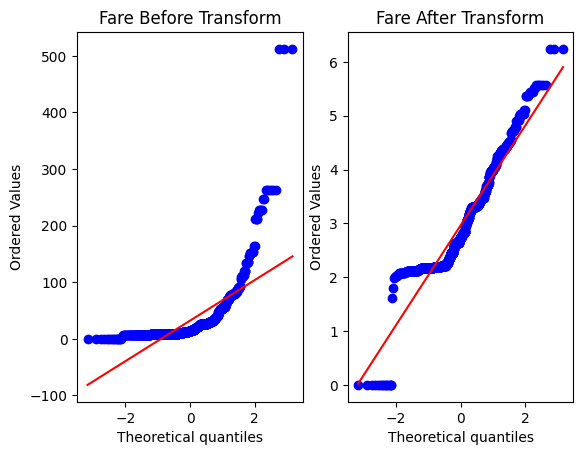

In [30]:
apply_transform(lambda x: x)

Accuracy  0.6712609238451936


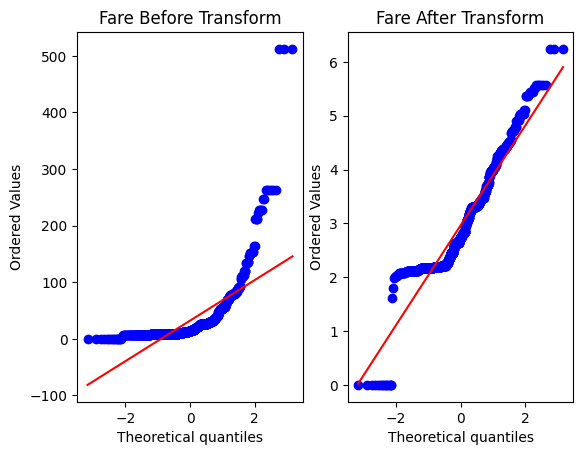

In [31]:
apply_transform(lambda x: x**2)

Accuracy  0.6712609238451936


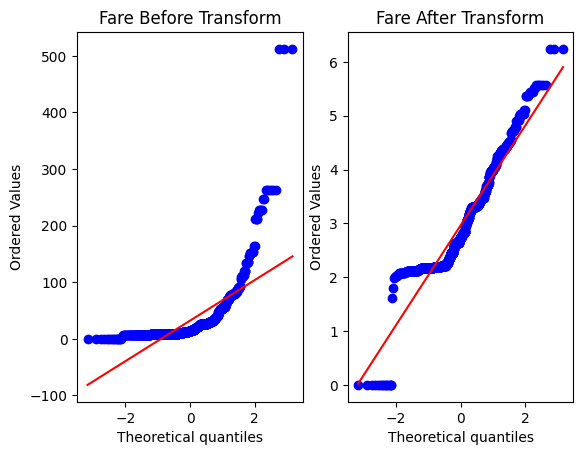

In [32]:
apply_transform(lambda x: x**1/2)